In [1]:
import os
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn import svm

# 定义数据预处理
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

# 提取训练集的特征向量和标签
train_features = []
train_labels = []

for images, labels in train_data:
    train_features.append(images.flatten().numpy())
    train_labels.append(labels)

# 初始化并训练SVM分类器
svm_classifier = svm.SVC()
svm_classifier.fit(train_features, train_labels)

# 提取测试集的特征向量和标签
test_features = []
test_labels = []
test_data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3/val'
test_dataset = datasets.ImageFolder(test_data_dir, data_transforms)
for images, labels in test_dataset:
    test_features.append(images.flatten().numpy())
    test_labels.append(labels)

# 使用训练好的分类器进行预测
predictions = svm_classifier.predict(test_features)

# 计算预测准确率
accuracy = (predictions == test_labels).mean()
print(f"Accuracy: {accuracy}")

Accuracy: 0.6785714285714286


In [3]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('SVM_con.png', dpi=300)
    plt.tight_layout()

In [5]:
cnf_matrix = confusion_matrix(test_labels, predictions)
print(cnf_matrix)

[[60  0  2  8]
 [15 25  0 30]
 [14  0 51  5]
 [12  3  1 54]]


Normalized confusion matrix
[[0.85714286 0.         0.02857143 0.11428571]
 [0.21428571 0.35714286 0.         0.42857143]
 [0.2        0.         0.72857143 0.07142857]
 [0.17142857 0.04285714 0.01428571 0.77142857]]


<ipython-input-3-e0d6dc220a02>:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


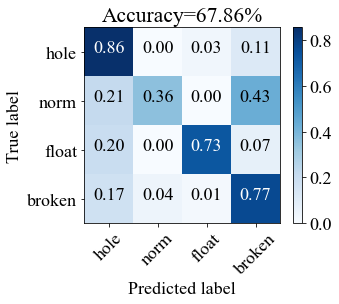

In [7]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_labels, predictions)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)